In [1]:
import pandas as pd 
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("tourist_accommodation_03112025_clean.csv")
data.head(10)

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,is_valid,ocupacion_mes
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2,1.0,...,10.0,10.0,10.0,0,0.406532,Spain,Málaga,2018-07-31,True,23
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,Cármenes,Latina,Private room,1,1,1.0,...,10.0,8.0,9.0,0,0.244807,Spain,Madrid,2020-10-01,True,30
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2.0,...,10.0,10.0,10.0,1,0.837420,Spain,Sevilla,2019-07-29,True,4
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,L'Antiga Esquerra De L'Eixample,Eixample,Private room,2,2,1.0,...,10.0,10.0,9.0,1,1.757272,Spain,Barcelona,2020-10-01,True,21
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1,2.0,...,10.0,10.0,10.0,0,0.207533,Spain,Girona,2019-02-19,True,30
5,48764,18th C Stone House near Costa Brava,Casa Fluvia is a charming stone village house ...,220145,Torroella De Fluvià,NaN,Entire home/apt,8,2,4.0,...,10.0,9.0,10.0,0,0.140792,Spain,Girona,2019-02-19,True,30
6,58512,Stylish & cozy 3BR near Sagrada Familia,Welcome to my home!<br /><br />My lovely 3 bed...,280070,El Camp De L'Arpa Del Clot,Sant Martí,Entire home/apt,6,2,3.0,...,9.0,9.0,9.0,1,2.200883,Spain,Barcelona,2020-12-10,True,0
7,71603,PENTHOUSE1 BEST PRICE 15/21.07 PROMO LAST MINUTE!,The apartment you are about to book has everyt...,366654,La Dreta De L'Eixample,Eixample,Entire home/apt,3,2,1.0,...,9.0,10.0,9.0,0,0.184152,Spain,Barcelona,2017-06-07,True,2
8,72150,Sunny attic duplex flat with terrace next to Sol,"The apartment is a quiet, secluded idyll in th...",364585,Embajadores,Centro,Entire home/apt,5,2,3.0,...,10.0,10.0,9.0,0,0.602342,Spain,Madrid,2020-06-11,True,1
9,73683,Sagrada Familia area for 12 people,"An ideal location for a big group, two apartme...",135703,El Camp D'En Grassot I Gràcia Nova,Gràcia,Entire home/apt,12,2,4.0,...,10.0,9.0,9.0,1,0.675803,Spain,Barcelona,2018-09-06,True,22


In [3]:
mark_data = data[["amenities_list","review_scores_location", "accommodates" ,"price", "city"]]
mark_data

,amenities_list,review_scores_location,accommodates,price,city
0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",10.0,2,400.0,Málaga
1,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",8.0,1,170.0,Madrid
2,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",10.0,4,990.0,Sevilla
3,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",10.0,2,400.0,Barcelona
4,"Wifi,Pool,Free parking on premises,Breakfast,P...",10.0,5,900.0,Girona
...,...,...,...,...,...
7529,"TV,Wifi,Elevator,Heating,Washer,Essentials,Sha...",0.0,1,3000.0,Barcelona
7530,"Patio or balcony, Long term stays allowed, Sha...",10.0,6,2090.0,Sevilla
7531,"Air conditioning,Pool,Kitchen,Free parking on ...",0.0,2,930.0,Mallorca
7532,"TV,Wifi,Air conditioning,Kitchen,Free parking ...",10.0,3,960.0,Barcelona


In [4]:
mark_data_decode = mark_data['amenities_list'].str.split(pat=",", expand=True)
mark_data_decode

,0,1,2,3,4,5,6,7,8,9,...,89,90,91,92,93,94,95,96,97,98
0,TV,Internet,Wifi,Air conditioning,Elevator,Buzzer/wireless intercom,Heating,Washer,Smoke detector,Carbon monoxide detector,...,None,None,None,None,None,None,None,None,None,None
1,TV,Internet,Wifi,Air conditioning,Kitchen,Free parking on premises,Doorman,Elevator,Heating,Washer,...,None,None,None,None,None,None,None,None,None,None
2,TV,Internet,Wifi,Air conditioning,Wheelchair accessible,Kitchen,Elevator,Buzzer/wireless intercom,Heating,Washer,...,None,None,None,None,None,None,None,None,None,None
3,TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Buzzer/wireless intercom,Heating,Washer,Essentials,...,None,None,None,None,None,None,None,None,None,None
4,Wifi,Pool,Free parking on premises,Breakfast,Pets live on this property,Dog(s),Cat(s),Other pet(s),Hot tub,Indoor fireplace,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,TV,Wifi,Elevator,Heating,Washer,Essentials,Shampoo,Lock on bedroom door,Hair dryer,Iron,...,None,None,None,None,None,None,None,None,None,None
7530,Patio or balcony,Long term stays allowed,Shampoo,Dedicated workspace,TV,Hot water,First aid kit,Kitchen,Host greets you,Paid parking off premises,...,None,None,None,None,None,None,None,None,None,None
7531,Air conditioning,Pool,Kitchen,Free parking on premises,Heating,Family/kid friendly,Iron,Microwave,Coffee maker,None,...,None,None,None,None,None,None,None,None,None,None
7532,TV,Wifi,Air conditioning,Kitchen,Free parking on premises,Elevator,Heating,Family/kid friendly,Washer,Dryer,...,None,None,None,None,None,None,None,None,None,None


In [5]:
mark_data_decode.values

array([['TV', 'Internet', 'Wifi', ..., None, None, None],
       ['TV', 'Internet', 'Wifi', ..., None, None, None],
       ['TV', 'Internet', 'Wifi', ..., None, None, None],
       ...,
       ['Air conditioning', 'Pool', 'Kitchen', ..., None, None, None],
       ['TV', 'Wifi', 'Air conditioning', ..., None, None, None],
       ['TV', 'Kitchen', 'Pets allowed', ..., None, None, None]],
      dtype=object)

In [6]:
mark_data_encoded = pd.get_dummies(mark_data_decode,) 
mark_data_encoded

,0_Air conditioning,0_BBQ grill,0_Baby bath,0_Babysitter recommendations,0_Baking sheet,0_Barbecue utensils,0_Bathtub,0_Beachfront,0_Bed linens,0_Bedroom comforts,...,89_Memory foam mattress,90_En suite bathroom,91_Outdoor seating,92_Mudroom,93_Full kitchen,94_Paid parking on premises,95_Bedroom comforts,96_Bathroom essentials,97_Fixed grab bars for shower,98_Shower chair
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7530,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7531,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7532,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
mark_data_encoded.shape

(7534, 7215)

In [8]:
for i in mark_data_encoded.columns:
    print(i)

0_Air conditioning
0_BBQ grill
0_Baby bath
0_Babysitter recommendations
0_Baking sheet
0_Barbecue utensils
0_Bathtub
0_Beachfront
0_Bed linens
0_Bedroom comforts
0_Breakfast
0_Building staff
0_Buzzer/wireless intercom
0_Cable TV
0_Carbon monoxide alarm
0_Changing table
0_Childrenu2019s dinnerware
0_Coffee maker
0_Conditioner
0_Cooking basics
0_Crib
0_Dedicated workspace
0_Dishes and silverware
0_Dishwasher
0_Dryer
0_Elevator
0_Elevator in building
0_Essentials
0_Extra pillows and blankets
0_Family/kid friendly
0_Fire extinguisher
0_First aid kit
0_Free parking on premises
0_Free street parking
0_Freezer
0_Garden or backyard
0_Hair dryer
0_Hangers
0_Heating
0_High chair
0_Host greets you
0_Hot tub
0_Hot water
0_Indoor fireplace
0_Internet
0_Iron
0_Keypad
0_Kitchen
0_Laptop friendly workspace
0_Laptop-friendly workspace
0_Lock on bedroom door
0_Lockbox
0_Long term stays allowed
0_Long term stays allowed]
0_Luggage dropoff allowed
0_Microwave
0_Outlet covers
0_Oven
0_Pack u2019n Play/trav

In [9]:
import re

def clean_column_names(df):
    """
    Clean pandas column names by:
    1. Removing numeric prefixes (0_, 1_, 2_, etc.)
    2. Removing special characters and brackets
    3. Handling translation missing entries
    4. Standardizing naming convention
    """
    cleaned_columns = []
    
    for col in df.columns:
        # Remove numeric prefixes (0_, 1_, 2_, etc.)
        cleaned = re.sub(r'^\d+_', '', col)
        
        # Remove trailing brackets and special characters
        cleaned = re.sub(r'[\[\]\]]', '', cleaned)
        
        # Handle translation missing entries
        if 'translation missing' in cleaned:
            # Extract the amenity number and create a standard name
            match = re.search(r'hosting_amenity_(\d+)', cleaned)
            if match:
                cleaned = f'amenity_{match.group(1)}'
            else:
                cleaned = 'unknown_amenity'
        
        # Replace special characters and u2019 (right single quote) with underscores
        cleaned = re.sub(r'[\/\\\u2019\s\-]', '_', cleaned)
        
        # Remove multiple consecutive underscores
        cleaned = re.sub(r'_+', '_', cleaned)

        #Replace � to "'"
        cleaned = re.sub(r'�', "'", cleaned)
        
        # Remove leading/trailing underscores
        cleaned = cleaned.strip('_')
        
        # Convert to lowercase
        cleaned = cleaned.lower()
        
        cleaned_columns.append(cleaned)
    
    return cleaned_columns




In [10]:
# Apply the cleaning to your DataFrame
mark_data_encoded.columns = clean_column_names(mark_data_encoded)

In [11]:
mark_data_encoded

,air_conditioning,bbq_grill,baby_bath,babysitter_recommendations,baking_sheet,barbecue_utensils,bathtub,beachfront,bed_linens,bedroom_comforts,...,memory_foam_mattress,en_suite_bathroom,outdoor_seating,mudroom,full_kitchen,paid_parking_on_premises,bedroom_comforts,bathroom_essentials,fixed_grab_bars_for_shower,shower_chair
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7530,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7531,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7532,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
mark_data_group= mark_data_encoded.groupby(by=mark_data_encoded.columns, axis=1 ).sum() 


In [13]:
full_data = pd.concat([mark_data, mark_data_group], axis=1) 
full_data
   

,amenities_list,review_scores_location,accommodates,price,city,,24_hour_check_in,40_hdtv,43_hdtv_with_netflix,accessible_height_bed,...,wide_entrance,wide_entrance_for_guests,wide_entryway,wide_hallway_clearance,wide_hallways,wifi,wifi_u2013_100_mbps,window_guards,wine_glasses,wireless_internet
0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",10.0,2,400.0,Málaga,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",8.0,1,170.0,Madrid,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",10.0,4,990.0,Sevilla,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",10.0,2,400.0,Barcelona,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,"Wifi,Pool,Free parking on premises,Breakfast,P...",10.0,5,900.0,Girona,0,1,0,0,0,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,"TV,Wifi,Elevator,Heating,Washer,Essentials,Sha...",0.0,1,3000.0,Barcelona,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7530,"Patio or balcony, Long term stays allowed, Sha...",10.0,6,2090.0,Sevilla,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7531,"Air conditioning,Pool,Kitchen,Free parking on ...",0.0,2,930.0,Mallorca,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7532,"TV,Wifi,Air conditioning,Kitchen,Free parking ...",10.0,3,960.0,Barcelona,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0


In [14]:
full_data=full_data.drop(["amenities_list",""], axis=1)
full_data

,review_scores_location,accommodates,price,city,24_hour_check_in,40_hdtv,43_hdtv_with_netflix,accessible_height_bed,accessible_height_toilet,air_conditioning,...,wide_entrance,wide_entrance_for_guests,wide_entryway,wide_hallway_clearance,wide_hallways,wifi,wifi_u2013_100_mbps,window_guards,wine_glasses,wireless_internet
0,10.0,2,400.0,Málaga,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,8.0,1,170.0,Madrid,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,10.0,4,990.0,Sevilla,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,10.0,2,400.0,Barcelona,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,10.0,5,900.0,Girona,1,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7529,0.0,1,3000.0,Barcelona,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
7530,10.0,6,2090.0,Sevilla,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
7531,0.0,2,930.0,Mallorca,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7532,10.0,3,960.0,Barcelona,0,0,0,0,0,1,...,0,0,0,0,1,1,0,0,0,0


### Separamos el dataframe por ciudades

In [16]:
ciudades = list(dict.fromkeys(full_data["city"].values ))
print(ciudades)

['Málaga', 'Madrid', 'Sevilla', 'Barcelona', 'Girona', 'Valencia', 'Mallorca', 'Menorca']


In [17]:
for x in ciudades:
    exec(f"data_{x} = full_data[full_data['city']== x].copy()")


### Feature importance

Random Forest Regression Feature Importance

#### Málaga

In [21]:
X = data_Málaga.drop(["price","city"], axis=1) 
y = data_Málaga["price"]

In [22]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [23]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [24]:
importance = model.feature_importances_

In [25]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.034 Column: review_scores_location
Feature: 1, Score: 0.256 Column: accommodates
Feature: 7, Score: 0.030 Column: air_conditioning
Feature: 9, Score: 0.012 Column: amenity_49
Feature: 25, Score: 0.010 Column: beachfront
Feature: 34, Score: 0.015 Column: building_staff
Feature: 47, Score: 0.024 Column: childrenu2019s_dinnerware
Feature: 67, Score: 0.028 Column: dryer
Feature: 84, Score: 0.015 Column: fire_extinguisher
Feature: 87, Score: 0.013 Column: first_aid_kit
Feature: 102, Score: 0.011 Column: game_console
Feature: 103, Score: 0.013 Column: garden_or_backyard
Feature: 114, Score: 0.013 Column: heating
Feature: 125, Score: 0.015 Column: kitchen
Feature: 131, Score: 0.028 Column: lockbox
Feature: 163, Score: 0.049 Column: pool
Feature: 170, Score: 0.017 Column: private_entrance
Feature: 171, Score: 0.028 Column: private_living_room
Feature: 179, Score: 0.013 Column: safety_card
Feature: 181, Score: 0.021 Column: shampoo
Feature: 205, Score: 0.014 Column: stove
F

<Axes: >

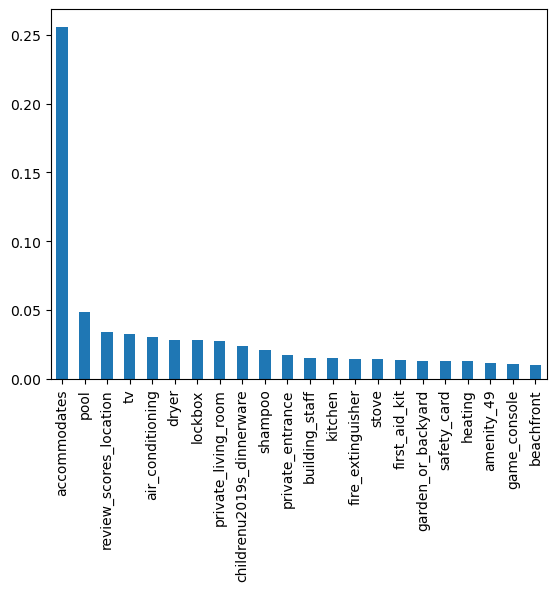

In [26]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Madrid

In [28]:
X = data_Madrid.drop(["price","city"], axis=1) 
y = data_Madrid["price"]

In [29]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [30]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [31]:
importance = model.feature_importances_

In [32]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.046 Column: review_scores_location
Feature: 1, Score: 0.300 Column: accommodates
Feature: 7, Score: 0.012 Column: air_conditioning
Feature: 36, Score: 0.014 Column: cable_tv
Feature: 56, Score: 0.026 Column: crib
Feature: 67, Score: 0.021 Column: dryer
Feature: 72, Score: 0.012 Column: elevator
Feature: 83, Score: 0.011 Column: family_kid_friendly
Feature: 84, Score: 0.012 Column: fire_extinguisher
Feature: 114, Score: 0.019 Column: heating
Feature: 121, Score: 0.011 Column: indoor_fireplace
Feature: 122, Score: 0.018 Column: internet
Feature: 128, Score: 0.034 Column: laptop_friendly_workspace
Feature: 132, Score: 0.011 Column: long_term_stays_allowed
Feature: 178, Score: 0.030 Column: room_darkening_shades
Feature: 179, Score: 0.010 Column: safety_card
Feature: 181, Score: 0.012 Column: shampoo
Feature: 193, Score: 0.017 Column: smoking_allowed
Feature: 218, Score: 0.012 Column: washer


<Axes: >

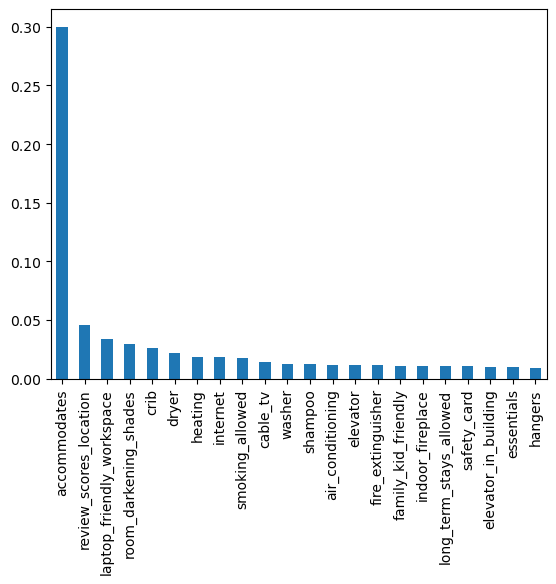

In [33]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Sevilla

In [35]:
X = data_Sevilla.drop(["price","city"], axis=1) 
y = data_Sevilla["price"]

In [36]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [37]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [38]:
importance = model.feature_importances_

In [39]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.077 Column: review_scores_location
Feature: 1, Score: 0.179 Column: accommodates
Feature: 2, Score: 0.014 Column: 24_hour_check_in
Feature: 10, Score: 0.014 Column: amenity_50
Feature: 26, Score: 0.010 Column: bed_linens
Feature: 55, Score: 0.016 Column: cooking_basics
Feature: 56, Score: 0.022 Column: crib
Feature: 83, Score: 0.015 Column: family_kid_friendly
Feature: 84, Score: 0.021 Column: fire_extinguisher
Feature: 87, Score: 0.025 Column: first_aid_kit
Feature: 96, Score: 0.018 Column: free_parking_on_premises
Feature: 98, Score: 0.045 Column: free_street_parking
Feature: 106, Score: 0.014 Column: gym
Feature: 107, Score: 0.019 Column: hair_dryer
Feature: 109, Score: 0.021 Column: handheld_shower_head
Feature: 110, Score: 0.012 Column: hangers
Feature: 115, Score: 0.041 Column: high_chair
Feature: 116, Score: 0.010 Column: host_greets_you
Feature: 118, Score: 0.022 Column: hot_water
Feature: 123, Score: 0.013 Column: iron
Feature: 124, Score: 0.017 Column: ke

<Axes: >

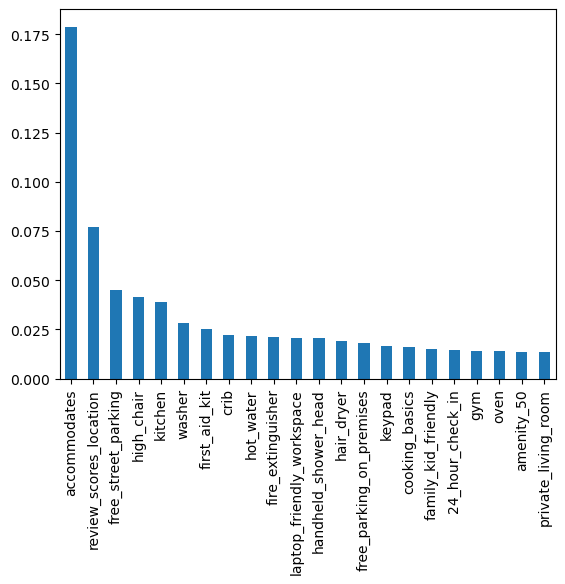

In [40]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Barcelona

In [42]:
X = data_Barcelona.drop(["price","city"], axis=1) 
y = data_Barcelona["price"]

In [43]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [44]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [45]:
importance = model.feature_importances_

In [46]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.037 Column: review_scores_location
Feature: 1, Score: 0.401 Column: accommodates
Feature: 2, Score: 0.018 Column: 24_hour_check_in
Feature: 7, Score: 0.018 Column: air_conditioning
Feature: 36, Score: 0.011 Column: cable_tv
Feature: 72, Score: 0.012 Column: elevator
Feature: 76, Score: 0.010 Column: essentials
Feature: 83, Score: 0.036 Column: family_kid_friendly
Feature: 114, Score: 0.012 Column: heating
Feature: 122, Score: 0.012 Column: internet
Feature: 128, Score: 0.013 Column: laptop_friendly_workspace
Feature: 133, Score: 0.011 Column: luggage_dropoff_allowed
Feature: 158, Score: 0.011 Column: patio_or_balcony
Feature: 163, Score: 0.011 Column: pool
Feature: 179, Score: 0.024 Column: safety_card
Feature: 181, Score: 0.014 Column: shampoo


<Axes: >

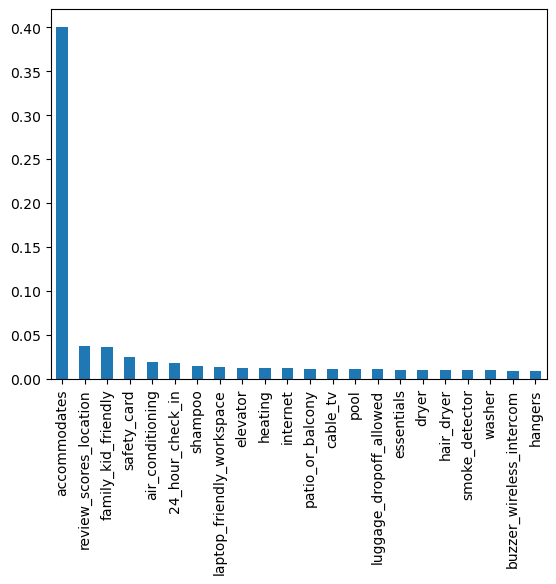

In [47]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Girona

In [93]:
X = data_Girona.drop(["price","city"], axis=1) 
y = data_Girona["price"]

In [95]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [97]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [99]:
importance = model.feature_importances_

In [101]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.036 Column: review_scores_location
Feature: 1, Score: 0.361 Column: accommodates
Feature: 7, Score: 0.013 Column: air_conditioning
Feature: 56, Score: 0.010 Column: crib
Feature: 67, Score: 0.025 Column: dryer
Feature: 72, Score: 0.015 Column: elevator
Feature: 76, Score: 0.010 Column: essentials
Feature: 103, Score: 0.010 Column: garden_or_backyard
Feature: 110, Score: 0.011 Column: hangers
Feature: 114, Score: 0.012 Column: heating
Feature: 121, Score: 0.030 Column: indoor_fireplace
Feature: 128, Score: 0.012 Column: laptop_friendly_workspace
Feature: 159, Score: 0.014 Column: pets_allowed
Feature: 163, Score: 0.045 Column: pool
Feature: 170, Score: 0.012 Column: private_entrance
Feature: 171, Score: 0.012 Column: private_living_room
Feature: 193, Score: 0.010 Column: smoking_allowed
Feature: 215, Score: 0.017 Column: tv
Feature: 228, Score: 0.011 Column: wide_entrance
Feature: 233, Score: 0.010 Column: wifi


<Axes: >

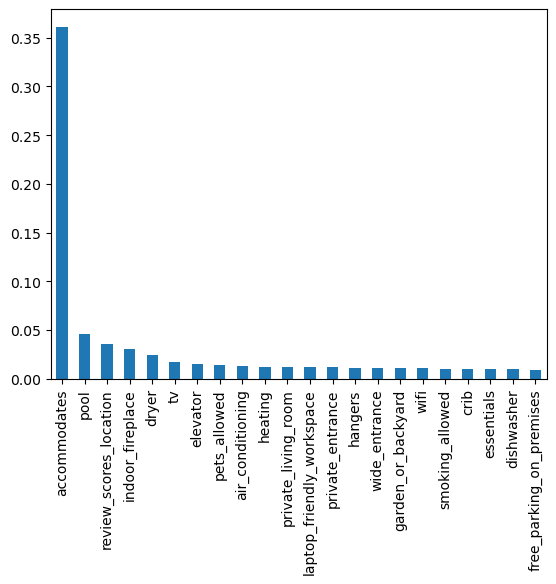

In [103]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Valencia

In [105]:
X = data_Valencia.drop(["price","city"], axis=1) 
y = data_Valencia["price"]

In [107]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [109]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [111]:
importance = model.feature_importances_

In [113]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.080 Column: review_scores_location
Feature: 1, Score: 0.250 Column: accommodates
Feature: 7, Score: 0.018 Column: air_conditioning
Feature: 26, Score: 0.015 Column: bed_linens
Feature: 58, Score: 0.011 Column: dedicated_workspace
Feature: 62, Score: 0.025 Column: dishwasher
Feature: 67, Score: 0.013 Column: dryer
Feature: 72, Score: 0.023 Column: elevator
Feature: 83, Score: 0.015 Column: family_kid_friendly
Feature: 84, Score: 0.014 Column: fire_extinguisher
Feature: 87, Score: 0.041 Column: first_aid_kit
Feature: 98, Score: 0.025 Column: free_street_parking
Feature: 116, Score: 0.012 Column: host_greets_you
Feature: 118, Score: 0.010 Column: hot_water
Feature: 123, Score: 0.011 Column: iron
Feature: 128, Score: 0.018 Column: laptop_friendly_workspace
Feature: 132, Score: 0.058 Column: long_term_stays_allowed
Feature: 156, Score: 0.013 Column: paid_parking_off_premises
Feature: 157, Score: 0.045 Column: paid_parking_on_premises
Feature: 158, Score: 0.022 Column: p

<Axes: >

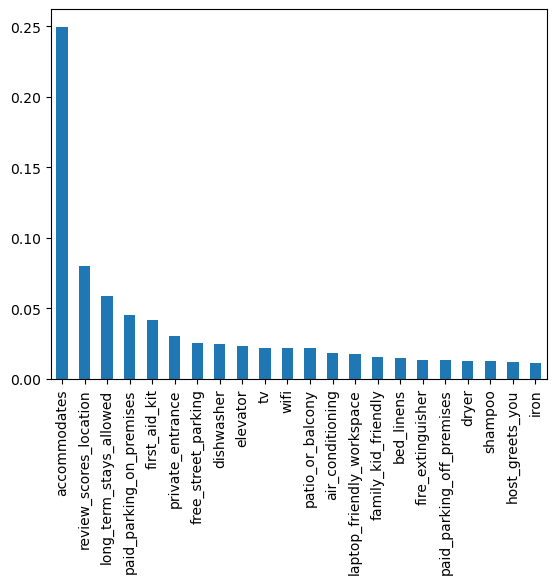

In [115]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Mallorca

In [117]:
X = data_Mallorca.drop(["price","city"], axis=1) 
y = data_Mallorca["price"]

In [119]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [121]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [123]:
importance = model.feature_importances_

In [125]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.041 Column: review_scores_location
Feature: 1, Score: 0.361 Column: accommodates
Feature: 7, Score: 0.015 Column: air_conditioning
Feature: 25, Score: 0.011 Column: beachfront
Feature: 36, Score: 0.013 Column: cable_tv
Feature: 56, Score: 0.012 Column: crib
Feature: 67, Score: 0.013 Column: dryer
Feature: 83, Score: 0.016 Column: family_kid_friendly
Feature: 96, Score: 0.011 Column: free_parking_on_premises
Feature: 114, Score: 0.013 Column: heating
Feature: 121, Score: 0.012 Column: indoor_fireplace
Feature: 122, Score: 0.014 Column: internet
Feature: 128, Score: 0.011 Column: laptop_friendly_workspace
Feature: 163, Score: 0.042 Column: pool
Feature: 179, Score: 0.010 Column: safety_card
Feature: 181, Score: 0.013 Column: shampoo
Feature: 193, Score: 0.013 Column: smoking_allowed
Feature: 206, Score: 0.012 Column: suitable_for_events


<Axes: >

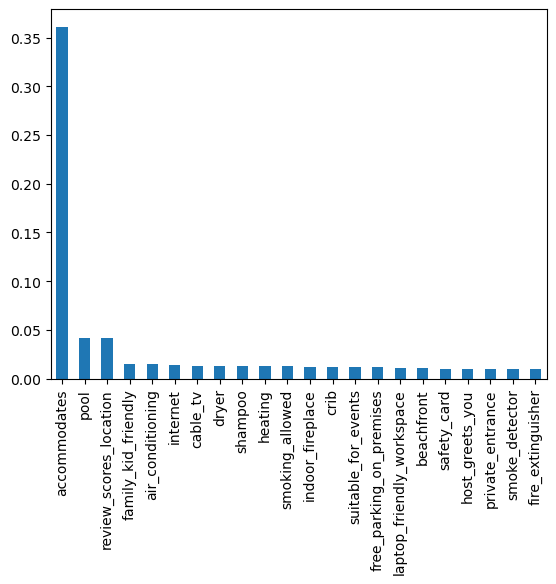

In [127]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))

#### Menorca

In [129]:
X = data_Menorca.drop(["price","city"], axis=1) 
y = data_Menorca["price"]

In [131]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [133]:
model.fit(X,y)

RandomForestRegressor(random_state=42)

In [135]:
importance = model.feature_importances_

In [137]:
filtered_index = []
for i,v in enumerate(importance):
    if v > 0.01:
        filtered_index.append(i)
        print("Feature: %0d, Score: %.3f " % (i,v) + "Column: " + X.columns[i])

Feature: 0, Score: 0.041 Column: review_scores_location
Feature: 1, Score: 0.482 Column: accommodates
Feature: 7, Score: 0.011 Column: air_conditioning
Feature: 25, Score: 0.011 Column: beachfront
Feature: 35, Score: 0.023 Column: buzzer_wireless_intercom
Feature: 46, Score: 0.017 Column: childrenu2019s_books_and_toys
Feature: 62, Score: 0.013 Column: dishwasher
Feature: 67, Score: 0.015 Column: dryer
Feature: 76, Score: 0.041 Column: essentials
Feature: 87, Score: 0.022 Column: first_aid_kit
Feature: 98, Score: 0.013 Column: free_street_parking
Feature: 121, Score: 0.015 Column: indoor_fireplace
Feature: 130, Score: 0.015 Column: lock_on_bedroom_door
Feature: 163, Score: 0.014 Column: pool
Feature: 171, Score: 0.012 Column: private_living_room
Feature: 233, Score: 0.020 Column: wifi


<Axes: >

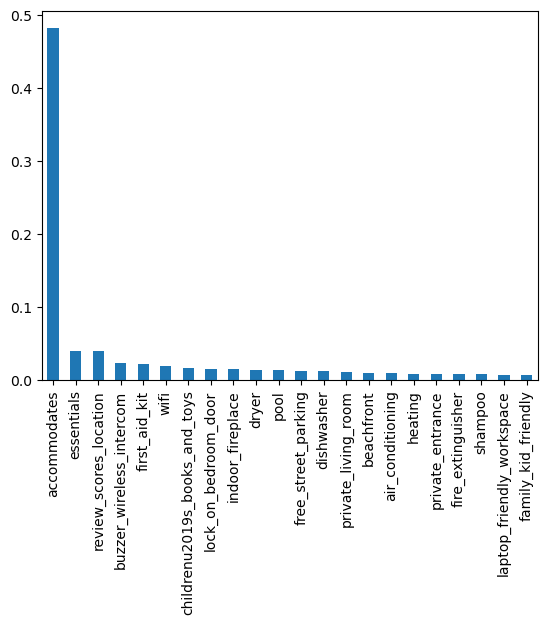

In [139]:
(pd.Series(model.feature_importances_, index=X.columns)
   .nlargest(22)
   .plot(kind='bar'))